In [3]:
import requests
import json
import re
import numpy as np
import pandas as pd
import math
import matplotlib.pyplot as plt
from IPython.core.display import HTML

![image](./mood-meter-2.png)

# Mood Meter

In [4]:
import pandas as pd

# Define the data for the Mood Meter
data = [
    # Red - High Energy Negative
    (1, 1, 'red', 'Enraged'), (1, 2, 'red', 'Panicked'), (1, 3, 'red', 'Stressed'), (1, 4, 'red', 'Jittery'), (1, 5, 'red', 'Shocked'),
    (2, 1, 'red', 'Livid'), (2, 2, 'red', 'Furious'), (2, 3, 'red', 'Frustrated'), (2, 4, 'red', 'Tense'), (2, 5, 'red', 'Stunned'),
    (3, 1, 'red', 'Fuming'), (3, 2, 'red', 'Frightened'), (3, 3, 'red', 'Angry'), (3, 4, 'red', 'Nervous'), (3, 5, 'red', 'Restless'),
    (4, 1, 'red', 'Anxious'), (4, 2, 'red', 'Apprehensive'), (4, 3, 'red', 'Worried'), (4, 4, 'red', 'Irritated'), (4, 5, 'red', 'Annoyed'),
    (5, 1, 'red', 'Repulsed'), (5, 2, 'red', 'Troubled'), (5, 3, 'red', 'Concerned'), (5, 4, 'red', 'Uneasy'), (5, 5, 'red', 'Peeved'),

    # Blue - Low Energy Negative
    (6, 1, 'blue', 'Disgusted'), (6, 2, 'blue', 'Glum'), (6, 3, 'blue', 'Disappointed'), (6, 4, 'blue', 'Down'), (6, 5, 'blue', 'Apathetic'),
    (7, 1, 'blue', 'Pessimistic'), (7, 2, 'blue', 'Morose'), (7, 3, 'blue', 'Discouraged'), (7, 4, 'blue', 'Sad'), (7, 5, 'blue', 'Bored'),
    (8, 1, 'blue', 'Alienated'), (8, 2, 'blue', 'Miserable'), (8, 3, 'blue', 'Lonely'), (8, 4, 'blue', 'Disheartened'), (8, 5, 'blue', 'Tired'),
    (9, 1, 'blue', 'Despondent'), (9, 2, 'blue', 'Depressed'), (9, 3, 'blue', 'Sullen'), (9, 4, 'blue', 'Exhausted'), (9, 5, 'blue', 'Fatigued'),
    (10, 1, 'blue', 'Despair'), (10, 2, 'blue', 'Hopeless'), (10, 3, 'blue', 'Desolate'), (10, 4, 'blue', 'Spent'), (10, 5, 'blue', 'Drained'),

    # Gold - High Energy Positive
    (1, 6, 'gold', 'Surprised'), (1, 7, 'gold', 'Upbeat'), (1, 8, 'gold', 'Festive'), (1, 9, 'gold', 'Exhilarated'), (1, 10, 'gold', 'Ecstatic'),
    (2, 6, 'gold', 'Hyper'), (2, 7, 'gold', 'Cheerful'), (2, 8, 'gold', 'Motivated'), (2, 9, 'gold', 'Inspired'), (2, 10, 'gold', 'Elated'),
    (3, 6, 'gold', 'Energized'), (3, 7, 'gold', 'Lively'), (3, 8, 'gold', 'Enthusiastic'), (3, 9, 'gold', 'Optimistic'), (3, 10, 'gold', 'Excited'),
    (4, 6, 'gold', 'Pleased'), (4, 7, 'gold', 'Happy'), (4, 8, 'gold', 'Focused'), (4, 9, 'gold', 'Proud'), (4, 10, 'gold', 'Thrilled'),
    (5, 6, 'gold', 'Pleasant'), (5, 7, 'gold', 'Joyful'), (5, 8, 'gold', 'Hopeful'), (5, 9, 'gold', 'Playful'), (5, 10, 'gold', 'Blissful'),

    # Green - Low Energy Positive
    (6, 6, 'green', 'At Ease'), (6, 7, 'green', 'Easygoing'), (6, 8, 'green', 'Content'), (6, 9, 'green', 'Loving'), (6, 10, 'green', 'Fulfilled'),
    (7, 6, 'green', 'Calm'), (7, 7, 'green', 'Secure'), (7, 8, 'green', 'Satisfied'), (7, 9, 'green', 'Grateful'), (7, 10, 'green', 'Touched'),
    (8, 6, 'green', 'Relaxed'), (8, 7, 'green', 'Chill'), (8, 8, 'green', 'Restful'), (8, 9, 'green', 'Blessed'), (8, 10, 'green', 'Balanced'),
    (9, 6, 'green', 'Mellow'), (9, 7, 'green', 'Thoughtful'), (9, 8, 'green', 'Peaceful'), (9, 9, 'green', 'Comfy'), (9, 10, 'green', 'Carefree'),
    (10, 6, 'green', 'Sleepy'), (10, 7, 'green', 'Complacent'), (10, 8, 'green', 'Tranquil'), (10, 9, 'green', 'Cozy'), (10, 10, 'green', 'Serene'),
]

# Create the DataFrame
mood_meter_orig = pd.DataFrame(data, columns=["row", "column", "color", "text"])
mood_meter_orig

,row,column,color,text
0,1,1,red,Enraged
1,1,2,red,Panicked
2,1,3,red,Stressed
3,1,4,red,Jittery
4,1,5,red,Shocked
...,...,...,...,...
95,10,6,green,Sleepy
96,10,7,green,Complacent
97,10,8,green,Tranquil
98,10,9,green,Cozy


## Alphabetical word list

In [5]:
alpha = pd.DataFrame({
    str(i) : c  
    for i,c in enumerate(np.split(np.array(sorted(mood_meter_orig['text'])),10))
})
alpha.columns = alpha.loc[0].apply(lambda x: x[0])
alpha

,A,B,D,E,F,H,L,P,S,T
0,Alienated,Bored,Depressed,Easygoing,Festive,Hopeful,Loving,Pessimistic,Satisfied,Tense
1,Angry,Calm,Desolate,Ecstatic,Focused,Hopeless,Mellow,Playful,Secure,Thoughtful
2,Annoyed,Carefree,Despair,Elated,Frightened,Hyper,Miserable,Pleasant,Serene,Thrilled
3,Anxious,Cheerful,Despondent,Energized,Frustrated,Inspired,Morose,Pleased,Shocked,Tired
4,Apathetic,Chill,Disappointed,Enraged,Fulfilled,Irritated,Motivated,Proud,Sleepy,Touched
5,Apprehensive,Comfy,Discouraged,Enthusiastic,Fuming,Jittery,Nervous,Relaxed,Spent,Tranquil
6,At Ease,Complacent,Disgusted,Excited,Furious,Joyful,Optimistic,Repulsed,Stressed,Troubled
7,Balanced,Concerned,Disheartened,Exhausted,Glum,Lively,Panicked,Restful,Stunned,Uneasy
8,Blessed,Content,Down,Exhilarated,Grateful,Livid,Peaceful,Restless,Sullen,Upbeat
9,Blissful,Cozy,Drained,Fatigued,Happy,Lonely,Peeved,Sad,Surprised,Worried


## Grid mapping

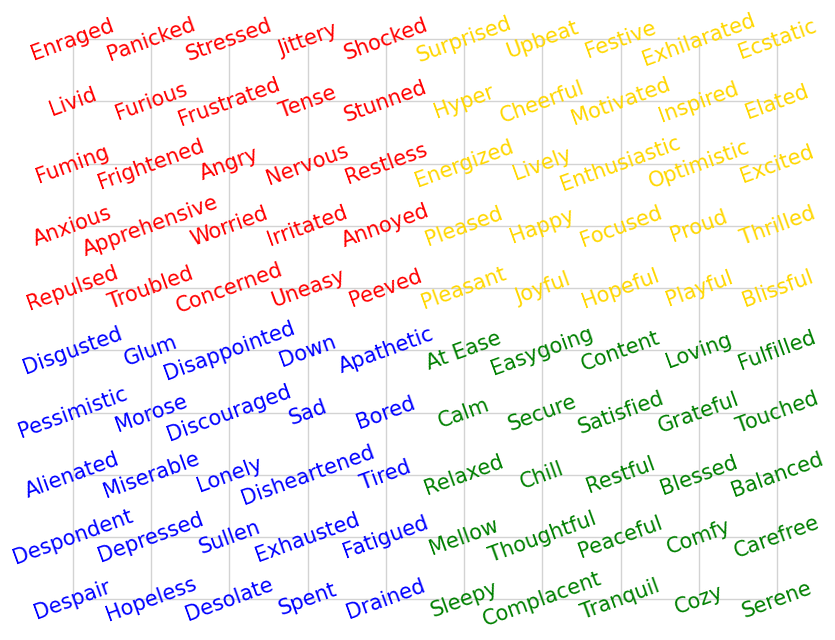

In [6]:
# Create the plot
fig, ax = plt.subplots(figsize=(10, 8))

# Draw the grid connecting adjacent cell positions
for row in range(1, 11):
    for col in range(1, 11):
        if col < 10:
            ax.plot([col, col + 1], [-row, -row], color='lightgray', linewidth=1)
        if row < 10:
            ax.plot([col, col], [-row, -(row + 1)], color='lightgray', linewidth=1)

# Plot each text label at its corresponding position
for _, row in mood_meter_orig.iterrows():
    ax.text(row['column'], -row['row'], row['text'], color=row['color'], 
            ha='center', va='center', fontsize=15, rotation=20)

# Set axis limits and remove axes

ax.axis('off')

# Show the plot
plt.show()

# Embedding

In [9]:
gpt_api_key=open('.openai_key', 'r').read().replace('\n','')
gpt_model="gpt-4o"
headers = {
    "Content-Type": "application/json",
    "Authorization": f"Bearer {gpt_api_key}"
}

In [10]:
def embedme(text):
    gpt_endpoint="https://api.openai.com/v1/embeddings"
    response= requests.post(gpt_endpoint, headers=headers, json={
        "input": text,
        "model": "text-embedding-3-small"
      })
    if response.status_code!=200:
        raise Exception(respons.text)
    return response.json()['data'][0]['embedding']

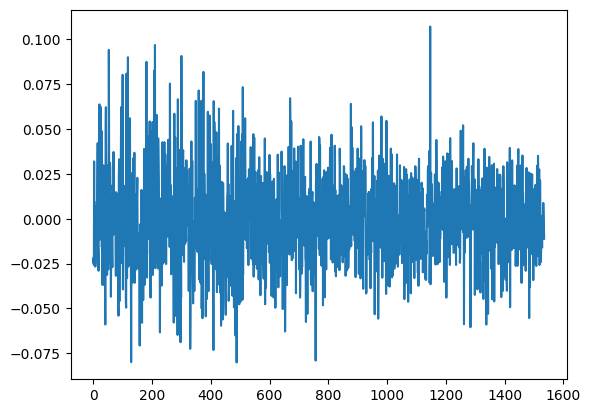

In [11]:
plt.plot(embedme('anger'))

# Wordwise embedding

In [14]:
mood_meter_shame= pd.concat([
    mood_meter_orig,
    pd.DataFrame([{'row':None, 'column':None, 'color':'black', 'text': 'Shame'}])
]).reset_index()

In [15]:
mood_meter_wordwise= mood_meter_shame.copy()
mood_meter_wordwise['embedding'] = mood_meter_wordwise['text'].apply(embedme)
mood_meter_wordwise

,index,row,column,color,text,embedding
0,0,1,1,red,Enraged,"[0.024388313, 0.005506052, -0.02456494, 0.0175..."
1,1,1,2,red,Panicked,"[0.00430137, -0.0119478395, -0.046432644, 0.04..."
2,2,1,3,red,Stressed,"[-0.0036989558, -0.006418178, -0.028305052, 0...."
3,3,1,4,red,Jittery,"[-0.038258374, -0.027701363, -0.07283474, -0.0..."
4,4,1,5,red,Shocked,"[-0.010630604, -0.018122973, -0.11216137, 0.08..."
...,...,...,...,...,...,...
96,96,10,7,green,Complacent,"[0.0753016, -0.026327774, -0.045069817, 0.0330..."
97,97,10,8,green,Tranquil,"[0.023419268, 0.024694974, -0.08438457, 0.0323..."
98,98,10,9,green,Cozy,"[0.0006804629, -0.039569896, -0.09272773, 0.02..."
99,99,10,10,green,Serene,"[0.03052066, -0.033601947, -0.06019131, 0.0399..."


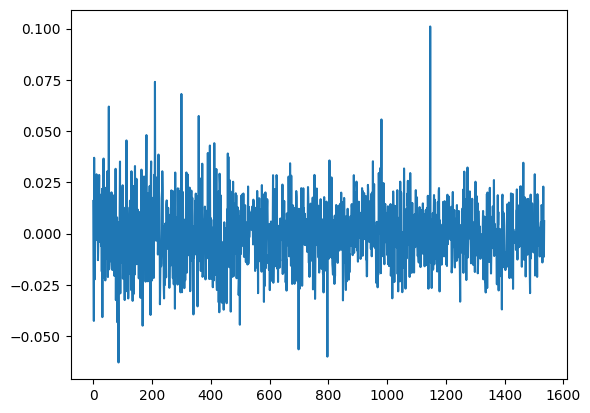

In [16]:
means= np.mean(np.array(mood_meter_wordwise['embedding'].tolist()),0)
plt.plot(means)

In [11]:
# Rotate the axis, such that the factors align with the original layout
def align_factors(mood_meter_df):
    mood_meter_df[['factor1','factor2']] = mood_meter_df[['factor1','factor2']] - mood_meter_df[['factor1','factor2']].mean()
    def mean(color1, color2):
        return mood_meter_df.query('color==@color1 or color==@color2')[['factor1', 'factor2']].mean().to_numpy()
    M= np.linalg.inv(np.array([
        mean('gold', 'green') - mean('red', 'blue'),
        mean('gold', 'red') - mean('green', 'blue')
    ]))
    mood_meter_df[['factor1','factor2']] = mood_meter_df[['factor1','factor2']].to_numpy() @ M

In [12]:
# Add new columns factor1 and factor2 to reflect the main components of the embedding
def apply_factors(mood_meter_df):
    # Compute the covariance matrix
    embeddings= np.array(mood_meter_df['embedding'].tolist())
    cov_matrix = np.cov(embeddings, rowvar=False)
    
    # Compute eigenvalues and eigenvectors
    eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)
    
    # Select the top two eigenvectors (principal components)
    principal_components = embeddings @ np.real(eigenvectors[:, :2])
    
    # Add the two principal components as new columns
    mood_meter_df['factor1'] = principal_components[:, 0]
    mood_meter_df['factor2'] = principal_components[:, 1]
    align_factors(mood_meter_df)

apply_factors(mood_meter_wordwise)
mood_meter_wordwise

,index,row,column,color,text,embedding,factor1,factor2
0,0,1,1,red,Enraged,"[0.024388313, 0.005506052, -0.02456494, 0.0175...",-0.767731,1.506539
1,1,1,2,red,Panicked,"[0.00430137, -0.0119478395, -0.046432644, 0.04...",-0.652970,0.640916
2,2,1,3,red,Stressed,"[-0.0036989558, -0.006418178, -0.028305052, 0....",-0.323307,0.403238
3,3,1,4,red,Jittery,"[-0.038258374, -0.027701363, -0.07283474, -0.0...",0.043647,0.098219
4,4,1,5,red,Shocked,"[-0.010630604, -0.018122973, -0.11216137, 0.08...",-0.651626,1.091760
...,...,...,...,...,...,...,...,...
96,96,10,7,green,Complacent,"[0.0753016, -0.026327774, -0.045069817, 0.0330...",0.508858,-0.526085
97,97,10,8,green,Tranquil,"[0.023419268, 0.024694974, -0.08438457, 0.0323...",0.691683,-1.102681
98,98,10,9,green,Cozy,"[0.0006804629, -0.039569896, -0.09272773, 0.02...",0.625440,-0.799375
99,99,10,10,green,Serene,"[0.03052066, -0.033601947, -0.06019131, 0.0399...",0.736874,-1.301963


## Opposite

In [ ]:
def opposite(mood_meter_df, text):
    mood_meter_df = mood_meter_wordwise.copy()
    M= np.array(mood_meter_df['embedding'].tolist())
    plus = np.array(mood_meter_df.query('text==@text')['embedding'].item())
    minus = 2*np.mean(M, 0) - plus
    order = np.mean((M-minus)**2, axis=1)
    return mood_meter_df.iloc[np.argsort(order)]
opposite(mood_meter_wordwise, 'Shame')['text']

## Mapping

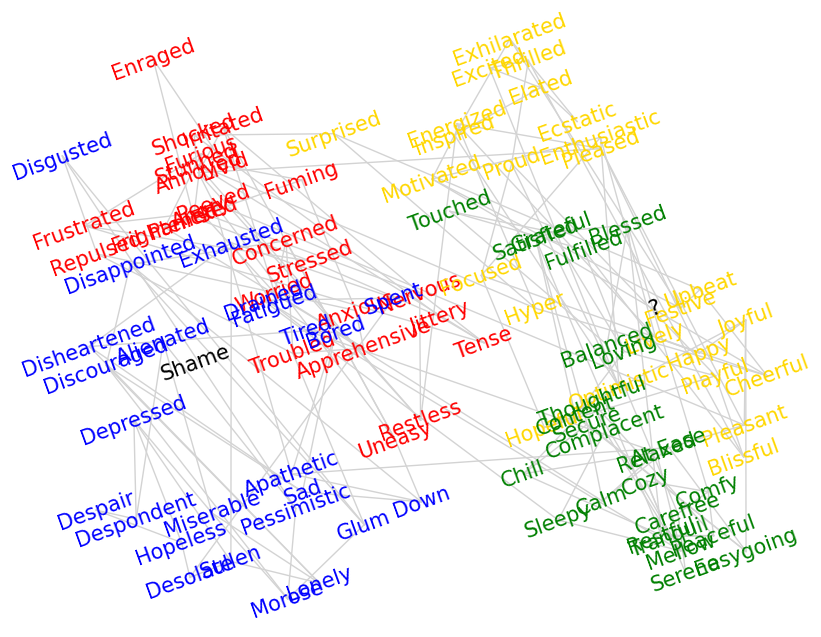

In [27]:
def plot_map(mood_meter_df):
    def X(row, col):
        return mood_meter_df.query('row==@row and column==@col')['factor1'].item()
    def Y(row, col):
        return mood_meter_df.query('row==@row and column==@col')['factor2'].item()
    # Create the plot
    fig, ax = plt.subplots(figsize=(10, 8))
    
    # Draw the grid connecting adjacent cell positions
    for row in range(1, 11):
        for col in range(1, 11):
            if col < 10:
                ax.plot([X(row, col), X(row,col + 1)], [Y(row,col), Y(row,col+1)], color='lightgray', linewidth=1)
            if row < 10:
                ax.plot([X(row, col), X(row+1, col)], [Y(row,col), Y(row + 1, col)], color='lightgray', linewidth=1)
    
    # Plot each text label at its corresponding position
    for _, row in mood_meter_df.iterrows():
        ax.text(row['factor1'], row['factor2'], row['text'], color=row['color'], 
                ha='center', va='center', fontsize=15, rotation=20)
    row= mood_meter_df.loc[100]
    ax.text(-row['factor1'], -row['factor2'], '?', color=row['color'], ha='center', va='center', fontsize=16, rotation=20)
    
    # Set axis limits and remove axes
    ax.axis('off')
    
    # Show the plot
    plt.show()
plot_map(mood_meter_wordwise)

# Expand it before embedding

In [12]:
def expand(text):
    gpt_endpoint="https://api.openai.com/v1/chat/completions"
    response= requests.post(gpt_endpoint, headers=headers, json={
        "messages": [
            { 
                "role": "user",
                "content": "Explain this emotion in short paragraph with special focus on activation and pleasure"
            }, {
                "role": "user",
                "content": text
            }],
        "model": "gpt-4o-mini"
      })
    if response.status_code!=200:
        raise Exception(response.text)
    return response.json()['choices'][0]['message']['content']

In [51]:
expand("Shame")

'Shame is a complex emotion characterized by feelings of inadequacy and humiliation, often arising from a perceived failure to meet social or personal standards. In terms of activation, shame can lead to a heightened physiological response, such as increased heart rate and a desire to withdraw or hide from others, reflecting its intense and often overwhelming nature. Pleasure, on the other hand, is distinctly absent in experiences of shame; instead, individuals may find the emotion aversive, prompting them to avoid situations that could evoke similar feelings in the future. Ultimately, shame can serve as a social regulator, signaling one’s need for connection and acceptance, but it often does so at the cost of personal joy and self-acceptance.'

In [28]:
mood_meter_expanded= mood_meter_shame.copy()
mood_meter_expanded['embedding'] = mood_meter_expanded['text'].apply(lambda text: embedme(expand(text)))
mood_meter_expanded

,index,row,column,color,text,embedding
0,0,1,1,red,Enraged,"[0.006210509, 0.023088023, -0.014967587, 0.019..."
1,1,1,2,red,Panicked,"[-0.0042702253, 0.010027349, -0.038855977, 0.0..."
2,2,1,3,red,Stressed,"[-0.0025892034, 0.0158893, -0.008138287, 0.024..."
3,3,1,4,red,Jittery,"[-0.027827652, 0.0010276543, -0.029286968, 0.0..."
4,4,1,5,red,Shocked,"[-0.014345721, 0.0025057285, -0.091856256, 0.0..."
...,...,...,...,...,...,...
96,96,10,7,green,Complacent,"[0.081979655, 0.027979575, -0.03619261, 0.0520..."
97,97,10,8,green,Tranquil,"[0.04537903, 0.0031268636, -0.028852936, 0.032..."
98,98,10,9,green,Cozy,"[0.05455681, -0.023233086, -0.053970177, 0.070..."
99,99,10,10,green,Serene,"[0.056107253, -0.003268152, -0.04754326, 0.062..."


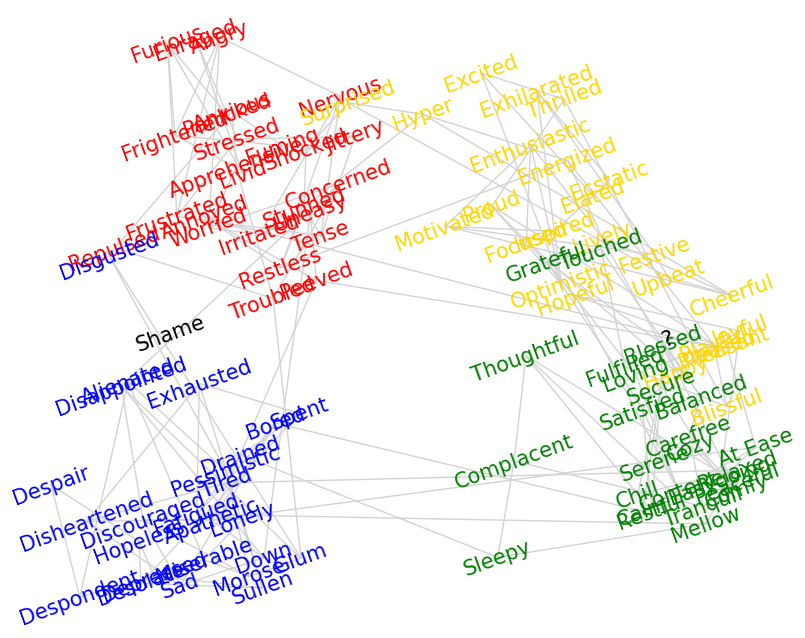

In [29]:
apply_factors(mood_meter_expanded)
plot_map(mood_meter_expanded)

In [18]:
opposite(mood_meter_expanded, 'Shame')['text'][:20]

85         Relaxed
63      Optimistic
62    Enthusiastic
72         Hopeful
54        Ecstatic
64         Excited
53     Exhilarated
66           Happy
51          Upbeat
56        Cheerful
15         Anxious
76       Easygoing
97        Tranquil
59          Elated
2         Stressed
14        Restless
82       Satisfied
71          Joyful
69        Thrilled
60       Energized
Name: text, dtype: object

In [24]:
opposite(mood_meter_expanded, 'Relaxed')['text'][:22]

38     Disheartened
25        Disgusted
40       Despondent
12            Angry
27     Disappointed
36        Miserable
0           Enraged
72          Hopeful
46         Hopeless
11       Frightened
45          Despair
19          Annoyed
47         Desolate
6           Furious
5             Livid
24           Peeved
32      Discouraged
7        Frustrated
58         Inspired
22        Concerned
4           Shocked
100           Shame
Name: text, dtype: object

In [8]:
opposite(mood_meter_expanded, 'Optimistic')['text'][:3]

25    Disgusted
4       Shocked
19      Annoyed
Name: text, dtype: object

In [9]:
opposite(mood_meter_expanded, 'Enthusiastic')['text'][:3]

41    Depressed
21     Troubled
42       Sullen
Name: text, dtype: object

# Rated explicitely

In [31]:
def rate_emotion(text):
    gpt_endpoint="https://api.openai.com/v1/chat/completions"
    response= requests.post(gpt_endpoint, headers=headers, json={
        "messages": [
            {   
                "role": "system",
                "content": "Return a json structure with two fields `pleasure` and `energy`. Pleasure rates the positivity of the emotion from 0 to 100. Energy rates the activation from 0 to 100."     
            }, { 
                "role": "user",
                "content": "Explain this emotion with a json structure"
            }, {
                "role": "user",
                "content": text
            }],
        "model": "gpt-4o"
      })
    if response.status_code!=200:
        raise Exception(response.text)
    a= response.json()['choices'][0]['message']['content']
    try:
        j= json.loads(re.search(r"\{.*\}", a.replace("\n","")).group(0))
        return [j['pleasure'], j['energy']]
    except:
        raise Exception(f"No json in {a}")

In [32]:
mood_meter_rated= mood_meter_shame.copy()
mood_meter_rated['embedding'] = mood_meter_rated['text'].apply(rate_emotion)
mood_meter_rated

,index,row,column,color,text,embedding
0,0,1,1,red,Enraged,"[10, 90]"
1,1,1,2,red,Panicked,"[20, 90]"
2,2,1,3,red,Stressed,"[20, 80]"
3,3,1,4,red,Jittery,"[30, 85]"
4,4,1,5,red,Shocked,"[30, 90]"
...,...,...,...,...,...,...
96,96,10,7,green,Complacent,"[65, 30]"
97,97,10,8,green,Tranquil,"[80, 20]"
98,98,10,9,green,Cozy,"[85, 30]"
99,99,10,10,green,Serene,"[85, 30]"


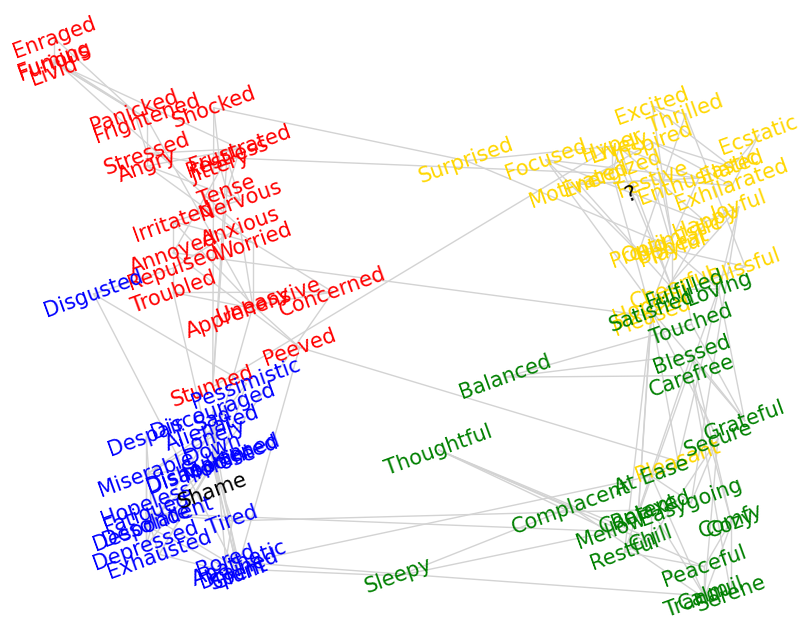

In [49]:
apply_factors(mood_meter_rated)
mood_meter_rated['factor2'] += np.random.normal(0, 0.1, (101,))
plot_map(mood_meter_rated)

In [39]:
opposite(mood_meter_rated, 'Shame')['text']

85          Relaxed
63       Optimistic
62     Enthusiastic
72          Hopeful
54         Ecstatic
           ...     
77          Content
20         Repulsed
25        Disgusted
45          Despair
100           Shame
Name: text, Length: 101, dtype: object